# Comparing PEFT Techniques

## Objective

This notebook compares three Parameter-Efficient Fine-Tuning methods:
- LoRA (Low-Rank Adaptation)
- DoRA (Weight-Decomposed LoRA)
- QLoRA (Quantized LoRA)

## Task

Multiclass classification on the AG News dataset

## Model

TinyLlama-1.1B-Chat-v1.0

## Installation

In [ ]:
!pip install -q transformers datasets peft accelerate bitsandbytes evaluate matplotlib scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.7 MB/s eta 0:00:00


## Imports and Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model
import evaluate


## Dataset Preparation

In [ ]:
dataset = load_dataset("ag_news")

num_labels = 4

tokenizer = AutoTokenizer.from_pretrained("TinyLlama/TinyLlama-1.1B-Chat-v1.0")
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

def tokenize(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

dataset = dataset.map(tokenize, batched=True)
dataset = dataset.rename_column("label", "labels")
dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

## Evaluation Metrics Setup

In [ ]:
accuracy = evaluate.load("accuracy")
precision = evaluate.load("precision")
recall = evaluate.load("recall")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy.compute(predictions=preds, references=labels)["accuracy"],
        "precision": precision.compute(predictions=preds, references=labels, average="macro")["precision"],
        "recall": recall.compute(predictions=preds, references=labels, average="macro")["recall"],
        "f1": f1.compute(predictions=preds, references=labels, average="macro")["f1"],
    }

def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


## LoRA

In [ ]:
model_lora = AutoModelForSequenceClassification.from_pretrained(
    "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    num_labels=num_labels,
    torch_dtype=torch.float16,
    device_map="auto"
)

model_lora.config.pad_token_id = tokenizer.pad_token_id


lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.1,
    bias="none",
    task_type="SEQ_CLS"
)

model_lora = get_peft_model(model_lora, lora_config)

training_args_lora = TrainingArguments(
    output_dir="/content/drive/MyDrive/Workshop/lora_out",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="epoch",
    num_train_epochs=1,
    logging_steps=100,
    save_strategy="no",
    fp16=False,
    bf16=True
)

trainer_lora = Trainer(
    model=model_lora,
    args=training_args_lora,
    train_dataset=dataset["train"].shuffle(seed=42).select(range(5000)),
    eval_dataset=dataset["test"].select(range(2000)),
    compute_metrics=compute_metrics
)

trainer_lora.train()
results_lora = trainer_lora.evaluate()
params_lora = count_trainable_params(model_lora)

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

LlamaForSequenceClassification LOAD REPORT from: TinyLlama/TinyLlama-1.1B-Chat-v1.0
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.407664,0.354108,0.889000,0.886968,0.886318,0.886513


In [ ]:
trainer_lora.model.save_pretrained("/content/drive/MyDrive/Workshop/lora_out")
tokenizer.save_pretrained('/content/drive/MyDrive/Workshop/lora_out')

import json

with open("/content/drive/MyDrive/Workshop/results_lora.json", "w") as f:
    json.dump(results_lora, f)

In [ ]:
results_lora

{'eval_loss': 0.35410773754119873,
 'eval_accuracy': 0.889,
 'eval_precision': 0.8869681040563546,
 'eval_recall': 0.8863176526985552,
 'eval_f1': 0.886512950424008,
 'eval_runtime': 239.923,
 'eval_samples_per_second': 8.336,
 'eval_steps_per_second': 1.042,
 'epoch': 1.0}

## QLoRA

In [ ]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4"
)

model_qlora = AutoModelForSequenceClassification.from_pretrained(
    "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    num_labels=num_labels,
    quantization_config=bnb_config,
    device_map="auto"
)
model_qlora.config.pad_token_id = tokenizer.pad_token_id

qlora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.1,
    bias="none",
    task_type="SEQ_CLS"
)

model_qlora = get_peft_model(model_qlora, qlora_config)

training_args_qlora = TrainingArguments(
    output_dir="/content/drive/MyDrive/Workshop/qlora_out",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="epoch",
    num_train_epochs=1,
    logging_steps=100,
    save_strategy="no",
    fp16=False,
    bf16=True
)

trainer_qlora = Trainer(
    model=model_qlora,
    args=training_args_qlora,
    train_dataset=dataset["train"].shuffle(seed=42).select(range(5000)),
    eval_dataset=dataset["test"].select(range(2000)),
    compute_metrics=compute_metrics
)

trainer_qlora.train()
results_qlora = trainer_qlora.evaluate()
params_qlora = count_trainable_params(model_qlora)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

LlamaForSequenceClassification LOAD REPORT from: TinyLlama/TinyLlama-1.1B-Chat-v1.0
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.406249,0.351122,0.880500,0.878600,0.878803,0.878613


In [ ]:
trainer_qlora.model.save_pretrained("/content/drive/MyDrive/Workshop/qlora_out")
tokenizer.save_pretrained('/content/drive/MyDrive/Workshop/qlora_out')

import json

with open("/content/drive/MyDrive/Workshop/results_qlora.json", "w") as f:
    json.dump(results_qlora, f)

In [ ]:
results_qlora

{'eval_loss': 0.3511216342449188,
 'eval_accuracy': 0.8805,
 'eval_precision': 0.8785999439581132,
 'eval_recall': 0.8788027298144536,
 'eval_f1': 0.878612667388346,
 'eval_runtime': 252.5512,
 'eval_samples_per_second': 7.919,
 'eval_steps_per_second': 0.99,
 'epoch': 1.0}

## DoRA

In [ ]:
dora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.1,
    bias="none",
    task_type="SEQ_CLS",
    use_dora=True
)

model_dora = AutoModelForSequenceClassification.from_pretrained(
    "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    num_labels=num_labels,
    torch_dtype=torch.float16,
    device_map="auto"
)
model_dora.config.pad_token_id = tokenizer.pad_token_id

model_dora = get_peft_model(model_dora, dora_config)

training_args_dora = TrainingArguments(
    output_dir="/content/drive/MyDrive/Workshop/dora_out",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="epoch",
    num_train_epochs=1,
    logging_steps=100,
    save_strategy="no",
    fp16=False,
    bf16=True
)

trainer_dora = Trainer(
    model=model_dora,
    args=training_args_dora,
    train_dataset=dataset["train"].shuffle(seed=42).select(range(5000)),
    eval_dataset=dataset["test"].select(range(2000)),
    compute_metrics=compute_metrics
)

trainer_dora.train()
results_dora = trainer_dora.evaluate()
params_dora = count_trainable_params(model_dora)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

LlamaForSequenceClassification LOAD REPORT from: TinyLlama/TinyLlama-1.1B-Chat-v1.0
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.379814,0.326109,0.895000,0.893076,0.892839,0.892887


In [ ]:
trainer_dora.model.save_pretrained("/content/drive/MyDrive/Workshop/dora_out")
tokenizer.save_pretrained('/content/drive/MyDrive/Workshop/dora_out')

import json

with open("/content/drive/MyDrive/Workshop/results_dora.json", "w") as f:
    json.dump(results_dora, f)

In [ ]:
results_dora

{'eval_loss': 0.3261086940765381,
 'eval_accuracy': 0.895,
 'eval_precision': 0.8930763174236456,
 'eval_recall': 0.8928386815201789,
 'eval_f1': 0.8928873883144565,
 'eval_runtime': 252.2078,
 'eval_samples_per_second': 7.93,
 'eval_steps_per_second': 0.991,
 'epoch': 1.0}

In [ ]:
with open("/content/drive/MyDrive/Workshop/results_lora.json", "r") as f:
    results_lora = json.load(f)

with open("/content/drive/MyDrive/Workshop/results_qlora.json", "r") as f:
    results_qlora = json.load(f)

## Comparative Analysis

In [ ]:
acc_lora = results_lora["eval_accuracy"]
acc_qlora = results_qlora["eval_accuracy"]
acc_dora = results_dora["eval_accuracy"]

techniques = ["LoRA", "QLoRA", "DoRA"]
accuracies = [acc_lora, acc_qlora, acc_dora]

print("LoRA Accuracy:", acc_lora)
print("QLoRA Accuracy:", acc_qlora)
print("DoRA Accuracy:", acc_dora)


LoRA Accuracy: 0.889
QLoRA Accuracy: 0.8805
DoRA Accuracy: 0.895


In [ ]:
import pandas as pd
results_df = pd.DataFrame({
    'Method': ['LoRA', 'DoRA', 'QLoRA'],
    'Accuracy': [
        results_lora['eval_accuracy'],
        results_dora['eval_accuracy'],
        results_qlora['eval_accuracy']
    ],
    'Precision': [
        results_lora['eval_precision'],
        results_dora['eval_precision'],
        results_qlora['eval_precision']
    ],
    'Recall': [
        results_lora['eval_recall'],
        results_dora['eval_recall'],
        results_qlora['eval_recall']
    ],
    'F1 Score': [
        results_lora['eval_f1'],
        results_dora['eval_f1'],
        results_qlora['eval_f1']
    ]
})

print("\n" + "="*80)
print("COMPARATIVE RESULTS")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)


COMPARATIVE RESULTS
Method  Accuracy  Precision   Recall  F1 Score
  LoRA    0.8890   0.886968 0.886318  0.886513
  DoRA    0.8950   0.893076 0.892839  0.892887
 QLoRA    0.8805   0.878600 0.878803  0.878613


## Performance Visualization

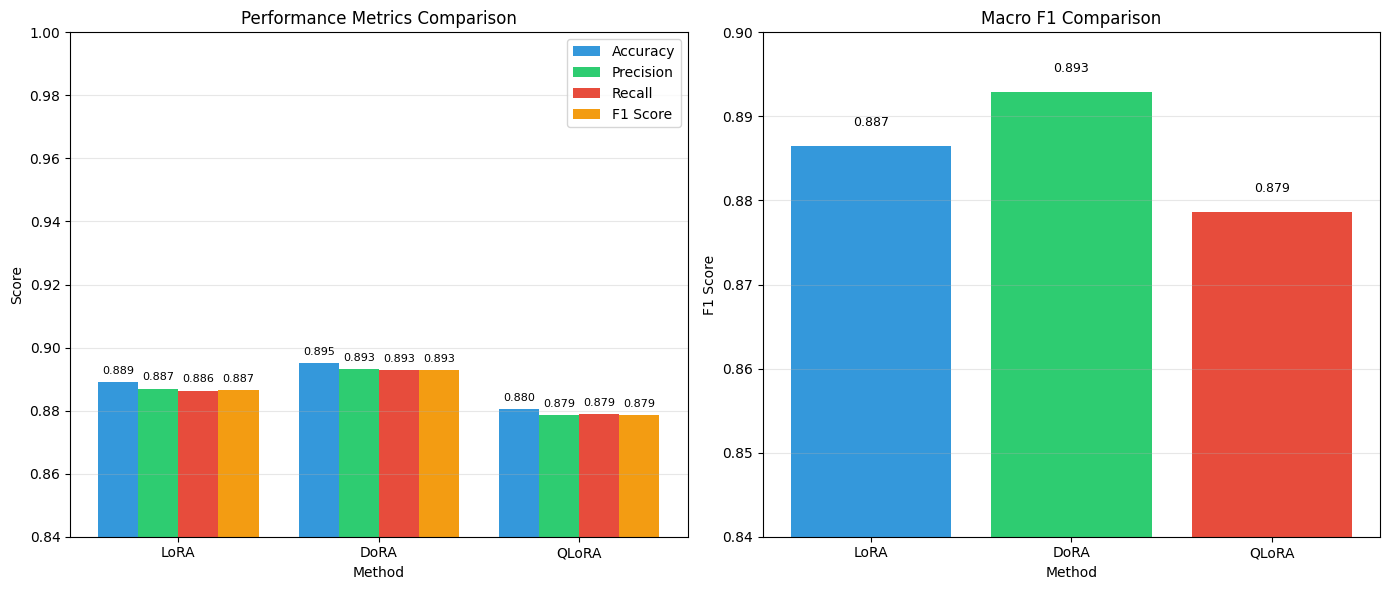

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

methods = ['LoRA', 'DoRA', 'QLoRA']
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

x = np.arange(len(methods))
width = 0.2

for i, metric in enumerate(metrics):
    values = results_df[metric].values
    bars = axes[0].bar(x + i*width, values, width, label=metric, color=colors[i])

    for bar in bars:
        height = bar.get_height()
        axes[0].text(
            bar.get_x() + bar.get_width()/2,
            height + 0.002,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            fontsize=8
        )

axes[0].set_ylabel('Score')
axes[0].set_xlabel('Method')
axes[0].set_title('Performance Metrics Comparison')
axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(methods)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0.84, 1.0])

f1_values = results_df['F1 Score'].values
bars = axes[1].bar(methods, f1_values, color=['#3498db', '#2ecc71', '#e74c3c'])

for bar in bars:
    height = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        height + 0.002,
        f'{height:.3f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

axes[1].set_ylabel('F1 Score')
axes[1].set_xlabel('Method')
axes[1].set_title('Macro F1 Comparison')
axes[1].set_ylim([0.84, 0.90])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## Key Findings

### Performance

All three methods achieve strong and closely clustered performance on AG News, with accuracy in the 85–89 percent range.

DoRA delivers the best overall results, achieving the highest accuracy, precision, recall, and F1 score among the three techniques.

LoRA performs very close to DoRA, with only a marginal drop across metrics, indicating that standard low-rank adaptation remains highly competitive.

QLoRA shows a modest reduction in performance compared to LoRA and DoRA, which is expected due to 4-bit quantization, yet it still maintains solid classification quality.

### Efficiency

LoRA and DoRA operate on full-precision base weights with lightweight adapters, resulting in stable training behavior and similar runtime characteristics.

DoRA introduces additional decomposition steps, which can slightly increase training overhead compared to LoRA.

QLoRA significantly reduces memory consumption through 4-bit quantization, making it more suitable for limited GPU environments such as standard Colab GPUs.

All three methods fine-tune only a small fraction of total parameters relative to the full model, keeping adaptation efficient and storage requirements low.

### Recommendations

Use LoRA when you want a strong, reliable baseline with minimal complexity and stable performance.

Use DoRA when marginal gains in accuracy and F1 matter and slightly higher computational overhead is acceptable.

Use QLoRA when memory is constrained or when scaling to larger base models where full-precision loading would not be feasible.